# Алгоритми визначення напряму потоку у гірських регіонах: D8, MFD, D∞

## Вступ і постановка проблеми

При аналізі цифрових моделей рельєфу (DEM) для визначення напрямків та накопичення стоку важливо правильно обрати алгоритм. У гірській місцевості (наприклад, Карпати) рельєф складний: **круті схили, чіткі хребти та глибокі улоговини** формують специфічні шляхи водотоків. Різні алгоритми моделювання стоку – від класичного **D8** до сучасніших **MFD** (multi-flow direction) та **D∞** – можуть давати дещо різні результати на такому рельєфі. Вибір методу впливає на те, де моделюється концентрація потоку, де починаються русла струмків, і яку площу накопичення отримає кожна точка.

У цій секції розглянемо основні алгоритми визначення напрямку потоку, їхні особливості та те, **які підходи зараз рекомендуються для гірських територій** згідно з актуальними дослідженнями. Будемо спиратися на наукові джерела і практичний досвід.

## Основні алгоритми моделювання потоку

Найпоширеніші алгоритми визначення напрямку стоку можна поділити на **однопоточні (SFD, single-flow direction)** та **багатопоточні (MFD, multiple-flow direction)**. Однопоточні моделі направляють весь потік з кожної комірки в одного сусіда, тоді як багатопоточні дозволяють розподіл води між декількома напрямками. Розглянемо три найвідоміші алгоритми: **D8**, **MFD (FD8)** та **D∞**.

### Алгоритм D8 (Deterministic 8)

Алгоритм **D8** – один з перших і найбільш простих. Він дозволяє потоку текти лише в один із 8 сусідніх пікселів (8 напрямків по решітці) – той, куди спадає найбільший перепад висоти. Таким чином, **вода спрямовується по напрямку найбільшого схилу**. Цей метод добре моделює **збіжний потік у долинах**, де вода природно стікає донизу в одне русло.

**Переваги D8:**

* Простота реалізації і швидкість обчислень.
* Чітке визначення русел: весь стік концентрується, тому легко виділити струмки та річки.
* Для задач визначення вододілів та басейнів D8 працює добре, оскільки кожна комірка належить лише одному басейну – *не виникає неоднозначності з “подвійною приналежністю”*. Саме тому D8 історично став стандартом для **делімітації водозборів**: навіть сучасні інструменти (наприклад, TauDEM від Д.Тарботона) на етапі побудови вододілів часто використовують саме D8.

**Недоліки D8:**

* **Ефект “гребінця” (grid bias):** через обмеження до 8 фіксованих напрямків, потоки можуть штучно утворювати прямі лінії під 45° або 90° до півночі, слідуючи за орієнтацією піксельної сітки, а не реальним рельєфом.
* **Відсутність розгалуження на схилах:** D8 **не вміє моделювати дивергенцію потоку**. На випуклих ділянках (хребти, верхні схили) реальний стік може розходитись у різні боки, а D8 вибере тільки один напрямок, іноді випадково (через дрібні шуми висот). Це призводить до недооцінки площі, що зволожується на схилах, і всієї води, що стікає лише в одне русло.

У гірському контексті D8 може **надто рано формувати русла**: оскільки весь потік концентрується, алгоритм швидко досягає порогу для початку струмка вище по схилу, ніж це було б при врахуванні розсіювання потоку.

### Алгоритм MFD (Multiple Flow Direction, також FD8)

**MFD** – цілий клас методів, перші з яких запропонували Quinn, Freeman та колеги (1991) для усунення недоліків D8. Ідея MFD: дозволити розподіл стоку з комірки між **декількома** сусідніми комірками, пропорційно крутизні схилів у їх напрямку. Таким чином можна моделювати ситуацію, коли вода розтікається широким фронтом або кількома рукавами на випуклих формах рельєфу.

**Особливості MFD:**

* Потік ділиться між **усіма сусідами, що нижче**, зазвичай за вагами нахилу. Наприклад, алгоритм FD8 (Freeman, 1991) розраховує долю стоку, яка йде до кожного нижчого сусіда, пропорційно різниці висот.
* MFD добре підходить для **моделювання вологозапасу на схилах і розподілу вологості**. В місцях поблизу вододілів, де D8 все одно направив би всю воду в один бік, MFD покаже, що вода трохи стікає і в сусідні западини. Це дає більш реалістичну **картину вологонакопичення в широких улоговинах і на плато**.

**Переваги MFD:**

* Уникає повністю артефактів від орієнтації сітки (зменшує grid bias).
* **Дозволяє модельованому потоку розгалужуватись**, що ближче до реальності на складному рельєфі, особливо для поверхневого та ґрунтового стоку поза основними руслами.
* Поліпшує розрахунок індексів на кшталт **топографічного вологісного індексу (TWI)**: дослідження показують, що TWI на основі MFD сильніше корелює з фактичною вологістю ґрунту, ніж TWI на основі D8. Зокрема, в експерименті у лісах Центральної Європи найкращий зв’язок з виміряною вологістю ґрунту показав варіант MFD (алгоритм MFD-md).

**Недоліки MFD:**

* **“Перерозсіювання” потоку:** класичний MFD (FD8) може *розподілити воду занадто широко*. Це проявляється в тому, що модель утворює **надто розпливчасті, широкі зони стоку** на схилах, а струмки починаються пізніше (далі вниз по схилу), ніж очікується. Іншими словами, MFD інколи **запізнюється з утворенням русел**, бо вода розпорошується і не досягає порогового об’єму достатньо швидко.
* У крайніх випадках MFD може створювати нереалістичну «пляму» зволоження там, де насправді є чіткий струмок. Це небажано, якщо мета – отримати чітку мережу русел.
* Через розсіювання є *невизначеність з вододілами*: клітина поблизу межі басейну може частково віднести стік і до сусіднього басейну. Для практичних задач **поділу водозборів MFD майже не використовують** – зазвичай спочатку застосовують D8, щоб отримати непересічні басейни, а MFD лишають для інших цілей.

### Алгоритм D∞ (Deterministic Infinity)

**D∞ (D-infinity)** – запропонований Д. Тарботоном (Tarboton, 1997) алгоритм, що поєднує риси SFD і MFD. Він визначає напрямок стоку **не дискретно на 8 сусідів, а як кут нахилу** у безперервному просторі. Тобто, у кожній комірці формується **трикутна площина максимальної крутизни** (враховуються висоти центру і сусідів), і обчислюється азимут схилу. Потім потік розподіляється **між двома найближчими сусідами** на той азимут – пропорційно тому, наскільки кут “наближений” до кожного з них. Якщо азимут точно в бік одного сусіда – фактично це як D8; якщо ж між двома – поділ між ними. Таким чином, D∞ дозволяє максимум *2 напрямки* зі 100%-ним врахуванням геометрії рельєфу.

**Переваги D∞:**

* **Зменшення артефактів сітки:** на відміну від D8, напрям може бути будь-яким (не тільки 45° кратно). Це **усуває регулярний “зубчастий” вигляд потоку** на карті, особливо на пологих схилах.
* **Обмежений поділ потоку:** на відміну від класичного MFD, алгоритм D∞ не розпилює воду по всім напрямкам, а тільки максимум на два. Це **запобігає надмірному розсіюванню**. Практично D∞ дає більш вузькі потоки, ближчі до D8, але з можливістю невеликої дивергенції, коли це доречно. За ступенем розгалуження потоків алгоритми можна впорядкувати так: **MFD (найбільше) > D∞ (помірно) > D8 (не розгалужує)**.
* D∞ добре себе зарекомендував у гірських районах для розрахунку **специфічної площі водозбору** (Specific Catchment Area) та моделей, чутливих до розподілу стоку. Наприклад, індекси вологозапасу чи ризику зсувів. У згаданому дослідженні на Тайвані (субтропічні гори) результати показали, що **D∞ займає проміжну позицію** між D8 та MFD: D8 дав найменшу площу нестабільних (насичених) схилів, MFD – найбільшу, а D∞ – середнє значення.

**Недоліки D∞:**

* Складність реалізації та **обчислювальні витрати** трохи вищі, ніж у D8 (хоча для сучасних комп’ютерів це не критично).
* D∞ все ще не гарантує чітких меж басейнів, якщо застосовувати його для вододілів (потік може частково перетікати через гребені). Тому для делімітації басейнів часто D∞ використовують разом з D8: спочатку D∞ для накопичення стоку, а для визначення самих меж – D8.
* Певна *концептуальна складність*: кутові значення потоку (float-значення азимута) важче інтерпретувати і візуалізувати, ніж індексовані 8 напрямків у D8. Проте ГІС-пакети це зазвичай приховують від користувача.

## Порівняння алгоритмів у гірському рельєфі

У горах рельєф характерний чергуванням **крутих схилів та виражених вододілів**. Як себе показують різні алгоритми за таких умов?

* **На стрімких ділянках і в долинах** всі алгоритми загалом сходяться: вода і так тече майже прямолінійно вниз. Тут D8, MFD і D∞ визначать схожі основні русла. Практичний досвід показує, що якщо моделювати **головну річкову мережу**, різниця між алгоритмами буде невелика, особливо за наявності порогу накопичення для початку струмка. Більшість великих потоків будуть однаковими (\~95% збігу ліній та меж за одним дослідженням) навіть при використанні різних алгоритмів, якщо правильно підібрати поріг для виділення русел.

* **В районі витоків, на хребтах та пологіших схилах** – відмінності стають помітними. **D8, будучи недисперсним, “тягне” струмки далі вгору**: тобто моделює початок потоку вище по схилу. **MFD навпаки “відсуває” початок струмків вниз** по схилу, бо розпорошена вода потребує зібрати більшу площу для досягнення порогу струмка. **D∞ дає проміжний результат**. Таким чином, **розташування вододілів і витоків струмків** може змінюватися залежно від алгоритму. У критичних випадках (напр. при моделюванні невеликих басейнів) D8 і MFD можуть дати дещо різні басейнові межі, бо MFD допускає частковий стік через гребінь. За необхідності можна застосувати після MFD пост-обробку для корекції вододілів, але частіше просто обирають D8 для цієї задачі.

* **Площа накопичення та вологість ґрунтів:** на **опуклих схилах** D8 часто **недооцінює площу, що реально зволожується**, адже відправляє всю воду тільки в один напрямок. MFD та D∞ показують більшу площу розподілу води. Наприклад, при моделюванні зсувів з використанням стабілітаційної моделі SHALSTAB було виявлено, що D8 прогнозує меншу зону потенційно насичених (і нестабільних) ґрунтів, а MFD – значно більшу. У дослідженні в тайванських горах площа нестійких схилів, передбачена MFD, була до **40% більшою**, ніж за D∞, тоді як D8 давав \~15% менше, ніж D∞. Тобто, за D8 “ризикових” зон менше, бо потік концентрується і швидше стікає, а за MFD вода більше розтікається і насичує схили. **Для оцінки схильності до зсувів чи вологості** це критично: різні алгоритми можуть змінити результат на десятки відсотків, тому порівнювати моделі слід **тільки при одному й тому ж обраному алгоритмі**.

* **Точність та помилки DEM:** у горах навіть невелика похибка висот може спрямувати D8-потік не в ту балку. MFD більш “поблажливі” до дрібних похибок – якщо одна комірка трохи нижча хибно, D8 віддасть їй весь стік, а MFD – лише частку, решта піде правильніше. Таким чином, на **шумних даних** MFD/D∞ можуть бути стійкішими, менш чутливими до локальних помилок DEM. З іншого боку, інколи **занадто згладжують реальність**, якщо помилка DEM вказує на наявність невеликого ярка, D8 його виділить, а MFD може проігнорувати, “розмивши” потік навколо.

## Рекомендації та сучасна практика

**Єдиного “ідеального” алгоритму на всі випадки немає** – вибір залежить від поставленої задачі. Сучасні підходи враховують, що **концентрація потоку в руслах** та **розсіювання потоку на схилах** – різні процеси, і іноді навіть комбінують методи.

Ось кілька порад, **що зараз “must have” для гірських ландшафтів** у різних сценаріях:

* **Делімітація водозборів, річкова мережа і русла:** Тут фахівці часто лишаються на боці **D8 або інших SFD** алгоритмів. Причина – необхідність однозначно розділити територію на басейни і отримати чіткі витоки. У горах вода у сформованому руслі рідко розтікається на декілька потоків, тому **D8 цілком виправданий для мережі струмків**. Практичне правило: **використовуй D8 для побудови каналізованих потоків**, щоб уникнути штучного “двозначного” членства пікселів у різних басейнах. Якщо турбує занадто ранній початок струмків – можна підвищити поріг накопичення або згладити DEM, але алгоритм бажано лишити недисперсним (D8, Rho8 тощо).

* **Моделювання розподілу вологи, стоку на схилах, ерозії:** Для таких задач **рекомендовано брати MFD-алгоритми, бажано сучасні**. Наприклад, **Tarboton’s D∞** часто згадується як оптимальний компроміс між точністю та уникненням артефактів. Вологість ґрунту, топографічний індекс (TWI), місця накопичення води на схилах – все це краще передається, коли потік може трохи розгалужуватися. Сучасні дослідження підтверджують, що MFD-методи дають більш фізично обґрунтовані результати для розподілених показників. Наприклад, **топографічний індекс на основі MFD** краще пояснює просторову варіацію вологості, ніж на основі D8. Тому **“must-have” для гірських екосистемних чи ґрунтових досліджень – використовувати MFD або D∞**.

* **Змішані підходи:** Деякі спеціалісти радять комбінувати. Наприклад, у моделі річкової мережі: основні магістральні потоки лишити за D8, а розрахунок площі водозбору (SCA) виконати D∞ з наступним нормуванням. Існують також покращені алгоритми, як-от **DEMON** (Costa-Cabral & Burges) чи модифіковані трикутні методи (Multiple Triangular Flow), які намагаються врахувати переваги D∞ і MFD. У SAGA GIS, зокрема, є опція *“Multiple Triangular”*, яку сам Тарботон визнав удосконаленням свого D∞. Такі алгоритми можуть бути корисні для специфічних випадків (наприклад, дуже складний рельєф або потреба уникнути дрібних похибок DEM). Однак вони менш поширені; у практиці зазвичай достатньо вибору між D8 та D∞/MFD.

* **Програмні інструменти:** Сучасні ГІС і спеціалізовані бібліотеки підтримують потрібні алгоритми. *ArcGIS Pro*, *WhiteboxTools*, *SAGA GIS*, *GRASS GIS*, *TauDEM* – всі мають реалізації D8, MFD, D∞. У тому ж Whitebox (що використовується в наведеному коді) є функції `d8_flow_accumulation`, `fd8_flow_accumulation`, `d_inf_flow_accumulation` тощо. Тобто, при необхідності можна легко спробувати альтернативний метод без зміни платформи. **Рекомендація: перевірити чутливість результатів**. Якщо, скажімо, модель зсувів дуже відрізняється між D8 і D∞ – варто обрати той алгоритм, що більше відповідає фізичній суті процесу (для зсувів це буде D∞ або MFD, бо враховує розсіювання потоку по схилу). Якщо різниця мінімальна – можна залишити класичний D8 для простоти й сумісності з традиційними підходами.

## Висновки

Для гірських територій сучасний підхід полягає **не у виборі одного “маст-хев” алгоритму для всього**, а у розумному поєднанні методів залежно від задачі. Коротко підсумовуючи:

* **D8** – як і раніше актуальний для чітких річкових мереж і водозборів; простий і надійний у виділенні русел, але може недооцінити розподіл потоку на схилах.
* **MFD (FD8)** – дозволяє потоку розходитись, що важливо для моделювання вологості та дифузних процесів, однак може надмірно згладжувати русла. У горах використовується обережно для аналізу схилових процесів.
* **D∞** – **сучасний рекомендований підхід** для багатьох гідрологічних та геоморфологічних задач в горах. Він зменшує артефакти сітки та моделює як концентрований, так і розгалужений потік помірно. Багато дослідників вважають D∞ оптимальним компромісом, і він підтримується у популярних інструментах (TauDEM, Whitebox тощо).

Таким чином, **“must have” в інструментарії геоаналізу гірських ландшафтів** – це вміння застосувати *правильний алгоритм для правильної задачі*. В ідеалі варто обчислити напрямок та накопичення стоку **обома підходами (SFD і MFD)** і порівняти. Якщо різниця суттєва – проаналізувати причини і надати перевагу тому методу, що краще описує реальний процес. Зрештою, мета – отримати найадекватнішу модель стоку, яка враховує складність гірського рельєфу і відповідає фізичній гідрології місцевості. Це відповідає сучасним тенденціям: *використовувати D8 для каналізованого потоку, але **обов’язково** використовувати алгоритми з дивергенцією (як-от D∞) для схилових процесів та індексів*. Такий підхід забезпечить найбільш повну та коректну картину водного режиму гірської території.

**Джерела:**

* Lindsay J. (WhiteboxTools) – рекомендації щодо вибору алгоритмів стоку для різних задач.
* Huang et al. 2007 – порівняння D8, FD8, D∞ у моделюванні зсувонебезпеки на гірському водозборі (різниця в прогнозі нестабільних зон до 40%).
* Freeman 1991, Quinn 1991 – оригінальний MFD (FD8) алгоритм, розроблений для врахування дивергенції потоку на схилах.
* Tarboton 1997 – алгоритм D∞ для зменшення похибок орієнтації сітки та контрольованого розподілу потоку.
* Практичні зауваги з форумів SAGA GIS (Thomas Grabs, 2008) – про ініціацію струмків: MFD vs D8 на гористій місцевості.
* ArcGIS Pro Documentation – підтримка алгоритмів D8, MFD, D∞ у сучасних ГІС та принцип роботи D8.
* Дослідження в Центральноєвропейських лісах – TWI з MFD краще відповідає вологості ґрунту, ніж з D8.
* StackExchange GIS – обговорення придатності D8 vs D∞: D8 добре для *взаємовиключних водозборів*, D∞ – для загального потоку, але різниця мінімальна, якщо топографія домінує.


In [5]:
from whitebox.whitebox_tools import WhiteboxTools
from pathlib import Path

# Вхідна папка з DEM після breach_depressions
dem_folder = Path("/mnt/c/Users/5302/OneDrive/PhD/paper_DEM_artickle/data/DATA_UTM/dem/breached_dems")
output_folder = dem_folder.parent / "flow_outputs"
output_folder.mkdir(exist_ok=True)

# Ініціалізація WhiteboxTools
wbt = WhiteboxTools()
wbt.set_working_dir(str(output_folder))

# Обробка кожного DEM у папці
dem_files = sorted(dem_folder.glob("*_breached.tif"))

for dem_path in dem_files:
    name = dem_path.stem.replace("_breached", "")  # базова назва DEM

    pointer_raster = output_folder / f"{name}_d8_pointer.tif"
    accum_raster = output_folder / f"{name}_d8_accum.tif"

    print(f"\n🧭 Обчислюється напрямок стоку для {name}")
    wbt.d8_pointer(
        dem=str(dem_path),
        output=str(pointer_raster)
    )

    print(f"💧 Обчислюється накопичення стоку для {name}")
    wbt.run_tool(
    "D8FlowAccumulation",
    [
        f"--dem={str(dem_path)}",
        f"--output={str(accum_raster)}",
        "--out_type=cells"
    ])


    print(f"✅ Завершено: {name}")

print(f"\n🎉 Усі результати збережено в: {output_folder}")





🧭 Обчислюється напрямок стоку для alos_dem_utm32635
./whitebox_tools --run="D8Pointer" --wd="/mnt/c/Users/5302/OneDrive/PhD/paper_DEM_artickle/data/DATA_UTM/dem/flow_outputs" --dem='/mnt/c/Users/5302/OneDrive/PhD/paper_DEM_artickle/data/DATA_UTM/dem/breached_dems/alos_dem_utm32635_breached.tif' --output='/mnt/c/Users/5302/OneDrive/PhD/paper_DEM_artickle/data/DATA_UTM/dem/flow_outputs/alos_dem_utm32635_d8_pointer.tif' -v --compress_rasters=False

****************************
* Welcome to D8Pointer     *
* Powered by WhiteboxTools *
* www.whiteboxgeo.com      *
****************************
Reading data...
Progress: 0%
Progress: 1%
Progress: 2%
Progress: 3%
Progress: 4%
Progress: 5%
Progress: 6%
Progress: 7%
Progress: 8%
Progress: 9%
Progress: 10%
Progress: 11%
Progress: 12%
Progress: 13%
Progress: 14%
Progress: 15%
Progress: 16%
Progress: 17%
Progress: 18%
Progress: 19%
Progress: 20%
Progress: 21%
Progress: 22%
Progress: 23%
Progress: 24%
Progress: 25%
Progress: 26%
Progress: 27%
Progre

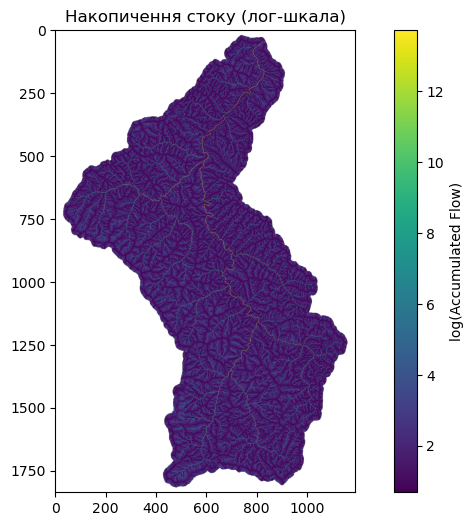

In [8]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

with rasterio.open("/mnt/c/Users/5302/OneDrive/PhD/paper_DEM_artickle/data/DATA_UTM/dem/flow_outputs/tan_dem_utm32635_d8_accum.tif") as src:
    data = src.read(1)
    safe_data = np.where((data > 0) & np.isfinite(data), data, np.nan)
    log_data = np.log1p(safe_data)

plt.figure(figsize=(10, 6))
plt.title("Накопичення стоку (лог-шкала)")
plt.imshow(log_data, cmap="viridis")
plt.colorbar(label="log(Accumulated Flow)")
plt.show()